# TP : Prédiction des frais d'assurance santé avec la régression et les KNN

## Objectif
Dans ce TP, vous allez explorer un jeu de données contenant des informations sur des personnes et leurs frais d'assurance. L'objectif est de prédire ces frais en utilisant des modèles de régression : régression linéaire et k plus proches voisins (KNN). Vous allez également analyser l'impact du nombre de voisins sur la performance du modèle KNN.

# 1. Importation des bibliothèques
Importer les bibliothèques nécessaires pour manipuler les données, les visualiser et construire les modèles de machine learning.

In [2]:
import pandas as pd

# 2. Chargement des données
Charger les données depuis le fichier insurance.csv disponible sur moodle.

In [3]:
df = pd.read_csv('../../../../Data/tp4/insurance.csv',sep=',')

# 3. Exploration des données
Analyser les premières lignes du dataset et quelques statistiques générales.

## Afficher les premières lignes du dataset

In [4]:
df.head(1)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884.924


## Afficher des statistiques générales sur les variables numériques

In [5]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


## Vérifier les valeurs manquantes

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Visualiser la distribution de la variable cible (charges) 

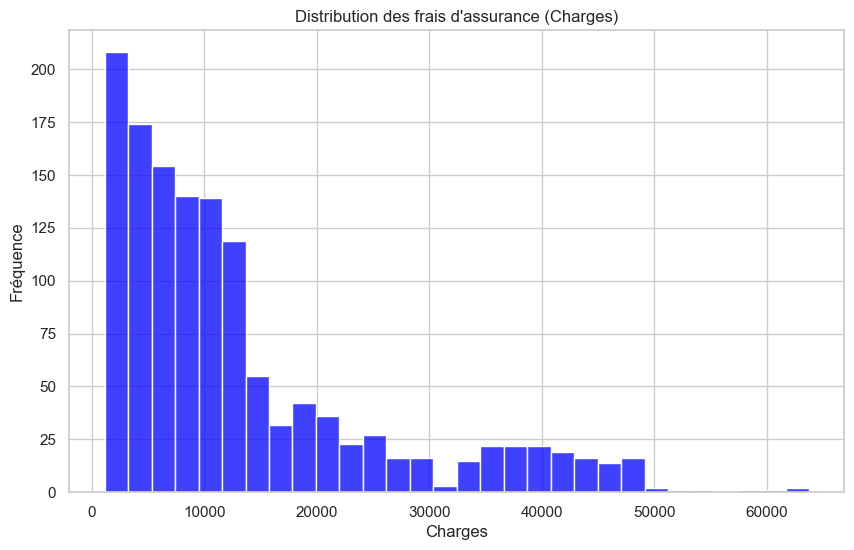

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set_theme(style="whitegrid")

# 创建画布
plt.figure(figsize=(10, 6))

# 画出 charges 的分布图（直方图 + 密度曲线）
sns.histplot(df['charges'], color='blue')

# 设置标题和标签（用法语或中文都可以，建议跟题目保持一致用法语）
plt.title("Distribution des frais d'assurance (Charges)")
plt.xlabel("Charges")
plt.ylabel("Fréquence")

# 显示图表
plt.show()

# 4. Prétraitement des données
### Encodage des variables catégorielles
Transformer les variables catégorielles en variables numériques avec `OrdinalEncoder`.

In [8]:
from sklearn.preprocessing import OrdinalEncoder

# 1. 初始化 OrdinalEncoder
encoder = OrdinalEncoder()

# 2. 指定需要转换的分类列
cat_cols = ['sex', 'smoker', 'region']

# 3. 对这些列进行转换处理
# fit_transform 会自动学习类别并将其替换为数字
df[cat_cols] = encoder.fit_transform(df[cat_cols])

# 4. 查看转换后的前几行，确认文字已经变成了数字
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0.0,27.900,0,1.0,3.0,16884.92400
1,18,1.0,33.770,1,0.0,2.0,1725.55230
2,28,1.0,33.000,3,0.0,2.0,4449.46200
3,33,1.0,22.705,0,0.0,1.0,21984.47061
4,32,1.0,28.880,0,0.0,1.0,3866.85520


### Normalisation des variables numériques
Normaliser les variables numériques pour les mettre à l'échelle en utilisant `StandardScaler` ou `MinMaxScaler`

In [9]:
from sklearn.preprocessing import StandardScaler

# 1. 选择需要缩放的数值型特征列
# 注意：charges 是我们的预测目标，通常不需要缩放，只缩放输入特征
num_cols = ['age', 'bmi', 'children']

# 2. 初始化 StandardScaler
scaler = StandardScaler()

# 3. 对这些列进行缩放处理
# fit_transform 会计算均值和标准差，并应用缩放
df[num_cols] = scaler.fit_transform(df[num_cols])

# 4. 再次查看查看数据统计，确认均值是否接近 0，标准差是否为 1
df[num_cols].describe()
# 或者直接 df.head() 查看数据
df.head()

,age,sex,bmi,children,smoker,region,charges
0,-1.438764,0.0,-0.453320,-0.908614,1.0,3.0,16884.92400
1,-1.509965,1.0,0.509621,-0.078767,0.0,2.0,1725.55230
2,-0.797954,1.0,0.383307,1.580926,0.0,2.0,4449.46200
3,-0.441948,1.0,-1.305531,-0.908614,0.0,1.0,21984.47061
4,-0.513149,1.0,-0.292556,-0.908614,0.0,1.0,3866.85520


### Construction du dataset final
Assembler les variables encodées et normalisées pour créer la matrice des caractéristiques `X` et la variable cible `y`.

In [10]:
# 1. 设置特征矩阵 X (包含除 charges 以外的所有列)
X = df.drop(columns=['charges'])

# 2. 设置目标变量 y (只包含 charges 这一列)
y = df['charges']

# 3. 打印 X 和 y 的形状确认一下
print(f"X 矩阵的大小: {X.shape}") # 应该是 (1338, 6)
print(f"y 向量的大小: {y.shape}") # 应该是 (1338,)

# 4. 查看 X 的前两行确认特征已经准备好
X.head(2)

X 矩阵的大小: (1338, 6)
y 向量的大小: (1338,)


,age,sex,bmi,children,smoker,region
0,-1.438764,0.0,-0.453320,-0.908614,1.0,3.0
1,-1.509965,1.0,0.509621,-0.078767,0.0,2.0


# 5. Division en ensembles d'entraînement et de test
Séparer les données en un ensemble d'entraînement (80%) et un ensemble de test (20%).

In [11]:
from sklearn.model_selection import train_test_split

# 使用 train_test_split 进行切分
# X: 特征, y: 目标
# test_size=0.2: 表示测试集占 20% (那么训练集自动占 80%)
# random_state=42: 这是一个随机种子，保证每次运行代码切分出来的结果都一样（方便调试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 打印各集合的大小确认
print(f"训练集特征大小: {X_train.shape}")
print(f"测试集特征大小: {X_test.shape}")
print(f"训练集目标大小: {y_train.shape}")
print(f"测试集目标大小: {y_test.shape}")

训练集特征大小: (1070, 6)
测试集特征大小: (268, 6)
训练集目标大小: (1070,)
测试集目标大小: (268,)


# 6. Implémentation d'un modèle de régression linéaire
Créer et entraîner un modèle de régression linéaire.

In [12]:
from sklearn.linear_model import LinearRegression

# 1. 初始化模型
model_Lr = LinearRegression()

# 2. 训练模型
model_Lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# 7. Prédictions et évaluation du modèle linéaire
Évaluer les performances du modèle avec l'erreur quadratique moyenne (MSE) et le coefficient de détermination (R²) sur le dataset d'entrainement et de test. Que pensez-vous de la qualité de ce modèle?

In [ ]:
# 3. 预测
y_pred = model_Lr.predict(X_test)

# 4. 评估模型
from sklearn.metrics import mean_squared_error, r2_score  # noqa: E402

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"均方误差: {mse}")
print(f"R^2: {r2}")

均方误差: 33635210.43117841
R^2: 0.7833463107364538


# 8. Implémentation d'un modèle KNN
Créer, entraîner et évaluer un modèle KNN avec `k=5`.

In [14]:
from sklearn.neighbors import KNeighborsRegressor

# 1. 初始化模型
model_Knn = KNeighborsRegressor(n_neighbors=5)

# 2. 训练模型
model_Knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# 9. Étude de l'impact du nombre de voisins
Tester l'effet du nombre de voisins sur la performance du modèle KNN.
Vous devez produire un graphique qui affiche la MSE en ordonnées en fonction du nombre voisin (en abscisse). Les valeurs en entrainement et en test doivent être affichées

In [ ]:
# 3. 预测
y_pred = model_Knn.predict(X_test)

# 4. 评估模型
from sklearn.metrics import mean_squared_error, r2_score  # noqa: E402  

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"均方误差: {mse}")
print(f"R^2: {r2}")

均方误差: 43067796.57255689
R^2: 0.7225884156429387


# 10. Analyse des résultats
- Quelle est l'importance des différentes variables dans la prédiction ?
- Quel est le meilleur choix pour le paramètre `k` ?

best_k: 4, min_mse: 40085181.18


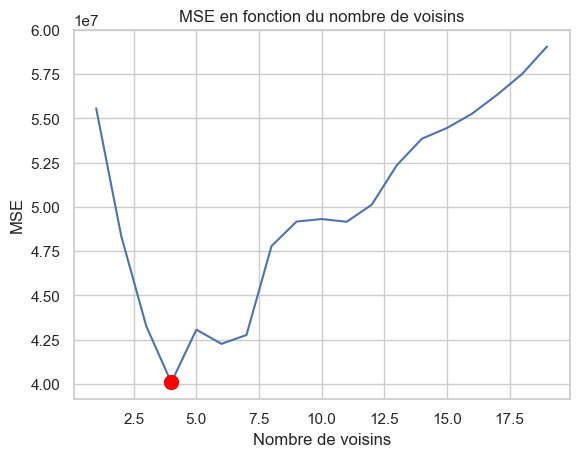

In [26]:
mse = []

for k in range(1, 20):
    model_Knn = KNeighborsRegressor(n_neighbors=k)
    model_Knn.fit(X_train, y_train)
    y_pred = model_Knn.predict(X_test)
    mse_temp = mean_squared_error(y_test, y_pred)
    mse.append(mse_temp)

min_mse = min(mse)
best_k = range(1, 20)[mse.index(min_mse)]
print(f"best_k: {best_k}, min_mse: {min_mse:.2f}")

plt.scatter(best_k, min_mse, color='red', s=100, zorder=5, label=f'Min MSE (k={best_k})')

plt.plot(range(1, 20), mse)
plt.title('MSE en fonction du nombre de voisins')
plt.xlabel('Nombre de voisins')
plt.ylabel('MSE')
plt.show()

# 11. Pour les plus rapides ou à faire à la maison
Améliorer l'analyse de paramètres précédentes pour répeter plusieurs fois les entraintements sur des splits train/test différents. Afficher sur le plot la moyenne et les écart-types obtenus sur 20 splits différents.

best_random_state:11,best_mse:27820275.589301053


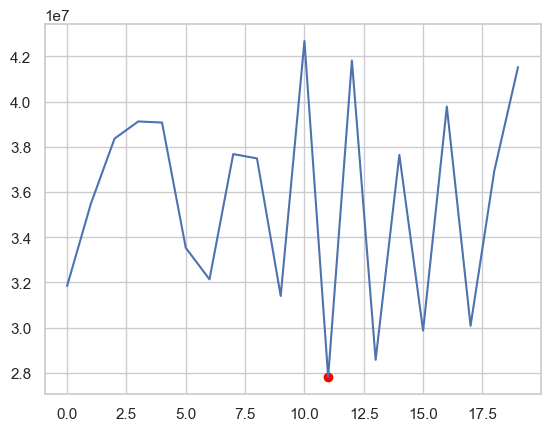

In [29]:
from matplotlib.pyplot import plot
result_lr_mse = []

for i in range(20):
    X_train_lr,X_test_lr,y_train_lr,y_test_lr = train_test_split(X,y,test_size=0.2,random_state=i)
    model_lr = LinearRegression()
    model_lr.fit(X_train_lr,y_train_lr)
    y_pred = model_lr.predict(X_test_lr)
    result_lr_mse.append(mean_squared_error(y_test_lr,y_pred))

best_i = result_lr_mse.index(min(result_lr_mse))
print(f"best_random_state:{best_i},best_mse:{result_lr_mse[best_i]}")

plt.scatter(best_i,result_lr_mse[best_i],color='red')
plt.plot(range(20),result_lr_mse)
plt.show()

best_random_state:13,best_mse:26284285.640753496


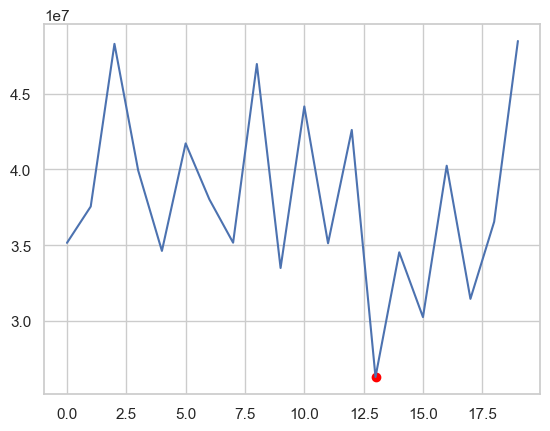

In [31]:
result_knn_mse = []

for i in range(20):
    X_train_knn,X_test_knn,y_train_knn,y_test_knn = train_test_split(X,y,test_size=0.2,random_state=i)
    result_knn_mse_temp = []
    for k in range(1,20):
        model_knn = KNeighborsRegressor(k)
        model_knn.fit(X_train_knn,y_train_knn)
        y_pred = model_knn.predict(X_test_knn)
        result_knn_mse_temp.append(mean_squared_error(y_test_knn,y_pred))
    result_knn_mse.append(min(result_knn_mse_temp))

best_i = result_knn_mse.index(min(result_knn_mse))
print(f"best_random_state:{best_i},best_mse:{result_knn_mse[best_i]}")

plt.plot(range(20),result_knn_mse)
plt.scatter(best_i,result_knn_mse[best_i],color='red')
plt.show()

# 12. Autres modèles
Tester d'autres modèles de regression linéaire "simples" tels que des modèles polynomiaux, Lasso, ElasticNet ou Ridge

In [34]:
import pandas as pd

data = pd.read_csv('../../../../Data/tp4/insurance.csv',sep=',')
data.head(1)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884.924


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

encoder = OneHotEncoder(sparse_output=False)
col = ['sex','smoker','region']
encoded_data = encoder.fit_transform(data[col])